In [29]:
import os
from pathlib import Path
import numpy as np
import pickle
import pooch
import tifffile
from careamics.lightning import VAEModule
import matplotlib.pyplot as plt
from microsplit_reproducibility.configs.factory import (
    create_algorithm_config,
    get_likelihood_config,
    get_loss_config,
    get_model_config
)
from microsplit_reproducibility.utils.io import load_checkpoint_path
from microsplit_reproducibility.utils.utils import plot_input_patches
from microsplit_reproducibility.datasets import create_train_val_datasets

# Dataset specific imports...
from microsplit_reproducibility.configs.parameters.custom_dataset_2D import (
    get_microsplit_parameters,
)
from microsplit_reproducibility.configs.data.custom_dataset_2D import get_data_configs
from microsplit_reproducibility.datasets.custom_dataset_2D import get_train_val_data


from usplit.core.tiff_reader import save_tiff, load_tiff

import random
import os
import numpy as np
import torch
import pickle
import ml_collections
import glob
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

from tqdm import tqdm
import numpy as np
from usplit.training import create_dataset, create_model
import matplotlib.pyplot as plt
from usplit.core.loss_type import LossType
from usplit.config_utils import load_config
from usplit.analysis.lvae_utils import get_img_from_forward_output
from usplit.analysis.plot_utils import clean_ax
from usplit.core.data_type import DataType
from usplit.core.psnr import PSNR
from usplit.analysis.plot_utils import get_k_largest_indices,plot_imgs_from_idx
from usplit.core.psnr import PSNR, RangeInvariantPsnr
from usplit.core.data_split_type import DataSplitType
from usplit.analysis.stitch_prediction import stitch_predictions
from usplit.analysis.mmse_prediction import get_dset_predictions
import pdb
from usplit.core.model_type import ModelType
torch.multiprocessing.set_sharing_strategy('file_system')

# %%

# %% [markdown]
# # **Step 2.1:** Data Preparation

# %% [markdown]
# ### OR path to your own data

dataset = "PAVIA_ATN"
dataset = "HAGEN"
if dataset == "PAVIA_ATN":
    DATA_PATH = Path("/group/jug/aman/Datasets/PAVIA_ATN")
    ckpt_dir= "/home/aman.kukde/Projects/models/paper_models/PaviaATN/ActTub/LeanLC/"
elif dataset == "HAGEN":
    DATA_PATH = Path("/group/jug/aman/Datasets/HAGEN")
    ckpt_dir= "/home/aman.kukde/Projects/models/paper_models/Hagen/MitoVsAct/LeanLC/"

NM_PATH = Path("./noise_models/")

# %% [markdown]
# ### Next, we load the image data to be processed

# %%
# setting up train, validation, and test data configs
img_sz = 64
multiscale_lowres_count = 5
sliding_window_flag = False

train_data_config, val_data_config, test_data_config = get_data_configs(
    image_size=(img_sz, img_sz), num_channels=2, sliding_window_flag= sliding_window_flag, multiscale_lowres_count = multiscale_lowres_count
)
# setting up MicroSplit parametrization
experiment_params = get_microsplit_parameters(
    algorithm = "musplit",
    img_size=(img_sz, img_sz),
    batch_size=32,
    num_epochs=10,
    multiscale_count=multiscale_lowres_count,
    noise_model_path=NM_PATH,
    target_channels=2,
)

# create the dataset
train_dset, val_dset, test_dset, data_stats = create_train_val_datasets(
    datapath=DATA_PATH,
    train_config=train_data_config,
    val_config=val_data_config,
    test_config=test_data_config,
    load_data_func=get_train_val_data,
)

Dataclass is <class 'careamics.lvae_training.dataset.lc_dataset.LCMultiChDloader'>

Padding is not used with this alignement style

Padding is not used with this alignement style

Padding is not used with this alignement style


In [30]:
# from usplit.core.tiff_reader import load_tiff
# img_win = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/windowed/pred_test_dset_pavia_usplit_windowed.tiff")
# img_og = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/original/pred_test_dset_pavia_usplit_og_64.tiff")

# img_win = img_win.transpose((0,2,3,1))
# img_og = img_og.transpose((0,2,3,1))


from usplit.core.tiff_reader import load_tiff
img_win = load_tiff(f'/group/jug/aman/results/Results_usplit_64/HAGEN/pred_test_dset_usplit_windowed.tiff').transpose(0,2,3,1)
img_og = load_tiff(f'/group/jug/aman/results/Results_usplit_64/HAGEN/pred_test_dset_usplit_og.tiff').transpose(0,2,3,1)

/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')
/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')


In [31]:
from microsplit_reproducibility.notebook_utils.custom_dataset_2D import (
    get_unnormalized_predictions,
    get_target,
    get_input,
)

inp = get_input(test_dset).sum(-1)
tar = get_target(test_dset)

In [39]:
from microsplit_reproducibility.utils.paper_metrics import compute_high_snr_stats, avg_range_inv_psnr
from tqdm import tqdm
stats_og = {}
stats_win = {}
for i in tqdm(range(len(img_og))):
    stats_og[i] = compute_high_snr_stats(tar[i:i+1], img_og[i:i+1])
    stats_win[i] = compute_high_snr_stats(tar[i:i+1], img_win[i:i+1])


import dill
if dataset == "PAVIA_ATN":
    with open("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/stats_og.pkl", "wb") as f:
        dill.dump(stats_og, f)
    with open("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/stats_win.pkl", "wb") as f:
        dill.dump(stats_win, f)
else:
    with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_og.pkl", "wb") as f:
        dill.dump(stats_og, f)
    with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_win.pkl", "wb") as f:
        dill.dump(stats_win, f)


100%|██████████| 1/1 [00:00<00:00,  1.47it/s]
/localscratch/cpm/envs/msr/lib/python3.10/site-packages/microssim/ssim/ssim_utils.py:297: RuntimeWarning: invalid value encountered in sqrt
  term = 2 * alpha * np.sqrt(elements.vx * elements.vy) + elements.C2
100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


PSNR on Highres 29.8+-0.0	29.99+-0.0
MicroSSIM on Highres 0.910+-0.000	0.912+-0.000
MicroS3IM on Highres 0.932+-0.000	0.956+-0.000
SSIM on Highres 0.919+-0.000	0.936+-0.000
MSSSIM on Highres 0.934+-0.000	0.959+-0.000


 10%|█         | 1/10 [00:21<03:09, 21.04s/it]

PSNR on Highres 29.89+-0.0	30.11+-0.0
MicroSSIM on Highres 0.910+-0.000	0.913+-0.000
MicroS3IM on Highres 0.933+-0.000	0.957+-0.000
SSIM on Highres 0.919+-0.000	0.937+-0.000
MSSSIM on Highres 0.936+-0.000	0.960+-0.000


100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


...

PSNR on Highres 30.65+-0.0	32.59+-0.0
MicroSSIM on Highres 0.937+-0.000	0.925+-0.000
MicroS3IM on Highres 0.953+-0.000	0.967+-0.000
SSIM on Highres 0.949+-0.000	0.961+-0.000
MSSSIM on Highres 0.958+-0.000	0.973+-0.000


100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


PSNR on Highres 29.56+-0.0	30.39+-0.0
MicroSSIM on Highres 0.924+-0.000	0.914+-0.000
MicroS3IM on Highres 0.953+-0.000	0.965+-0.000
SSIM on Highres 0.940+-0.000	0.947+-0.000
MSSSIM on Highres 0.957+-0.000	0.969+-0.000


100%|██████████| 10/10 [03:38<00:00, 21.84s/it]

PSNR on Highres 29.6+-0.0	30.44+-0.0
MicroSSIM on Highres 0.925+-0.000	0.915+-0.000
MicroS3IM on Highres 0.953+-0.000	0.965+-0.000
SSIM on Highres 0.940+-0.000	0.948+-0.000
MSSSIM on Highres 0.957+-0.000	0.969+-0.000


/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')
/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')


In [21]:
import dill
if dataset == "PAVIA_ATN":
    with open("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/stats_og.pkl", "rb") as f:
        stats_og = dill.load(f)
    with open("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/stats_win.pkl", "rb") as f:
        stats_win = dill.load(f)
else:

    with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_win.pkl", "rb") as f:
        stats_win= dill.load(f)
    with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_og.pkl", "rb") as f:
        stats_og = dill.load(f)

In [ ]:
# print("Metric, followed by values for each channel")
# from microsplit_reproducibility.utils.paper_metrics import compute_high_snr_stats
# stats_win = compute_high_snr_stats(test_dset._data, img_win)
# stats_og = compute_high_snr_stats(test_dset._data, img_og)

# import dill
# with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_win.pkl", "wb") as f:
#     dill.dump(stats_win, f)
# with open("/group/jug/aman/results/Results_usplit_64/HAGEN/stats_og.pkl", "wb") as f:
#     dill.dump(stats_og, f)

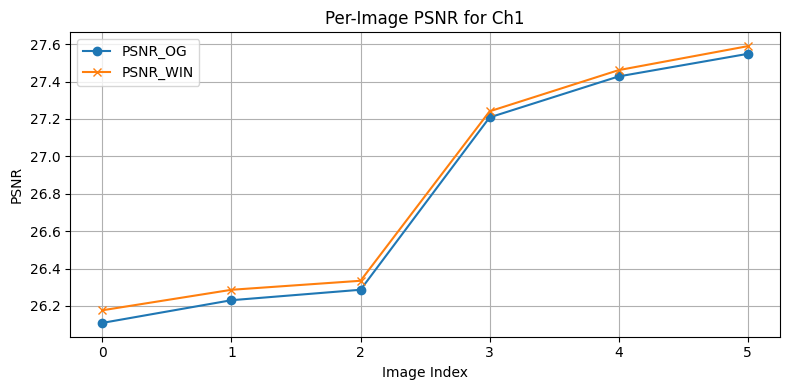

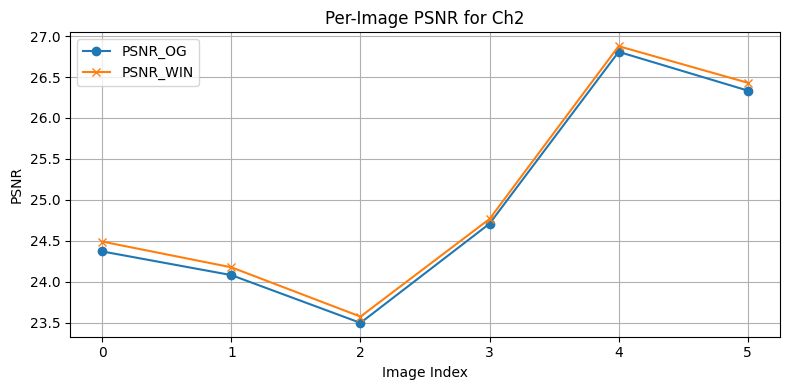

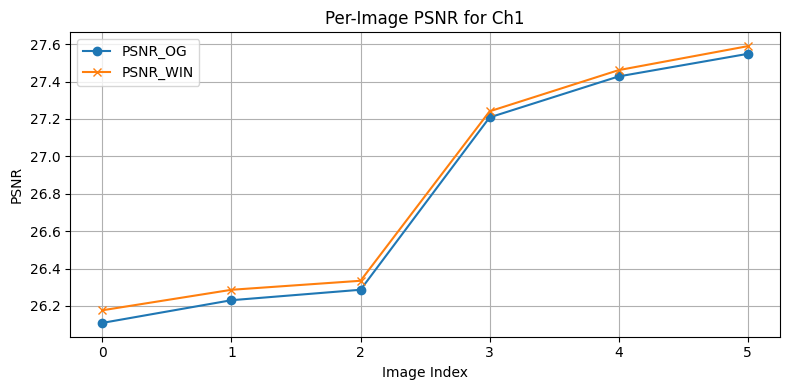

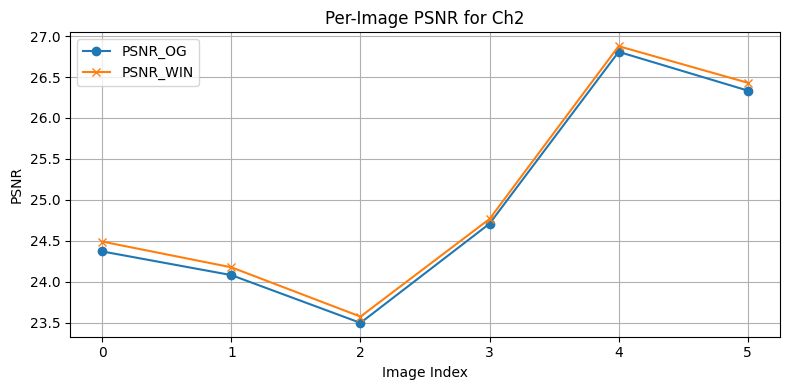

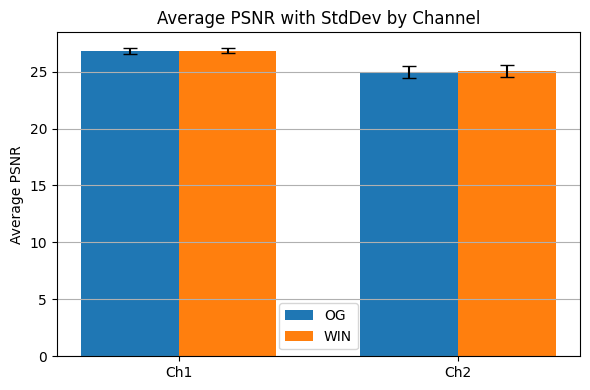

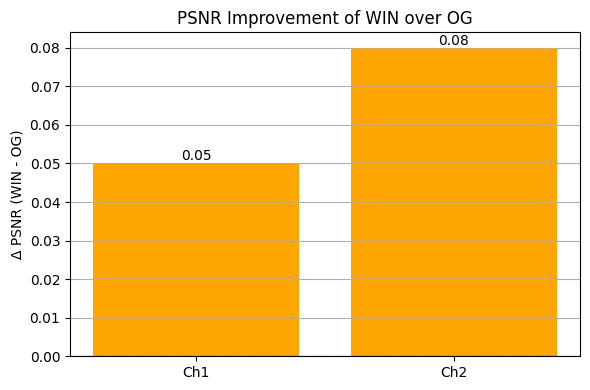

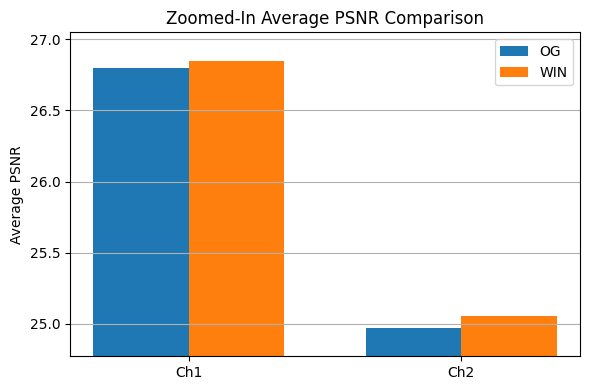

,Channel,Avg_PSNR_OG,Std_OG,Avg_PSNR_WIN,Std_WIN,SE_OG,SE_WIN
0,Ch1,26.80,0.246,26.85,0.242,0.1,0.099
1,Ch2,24.97,0.490,25.05,0.488,0.2,0.199


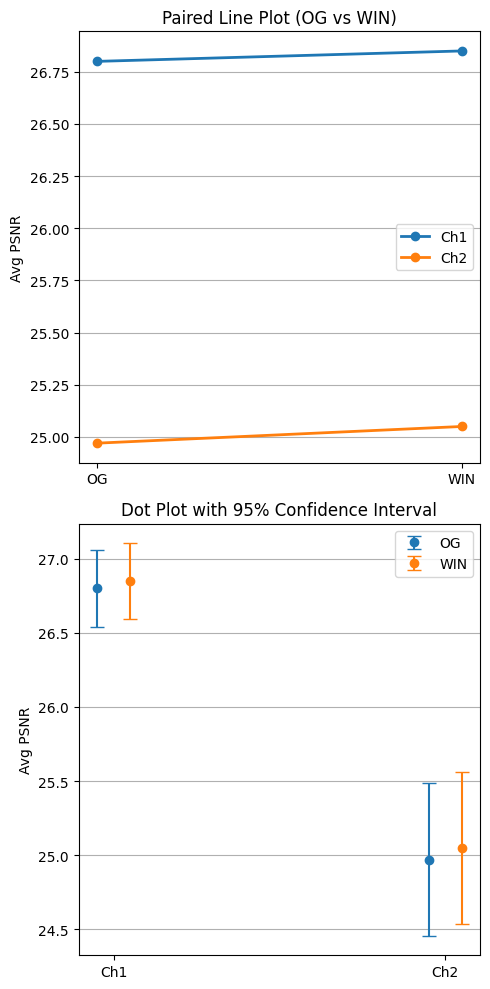

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from microsplit_reproducibility.utils.paper_metrics import RangeInvariantPsnr, avg_range_inv_psnr

def compute_psnr(test_data, img_og, img_win):
    records = []

    for i in range(6):  # Sample count
        tar = test_data[i:i+1]
        inp_win = img_win[i:i+1]
        inp_og = img_og[i:i+1]

        for ch in range(2):  # Channel loop
            psnr_og = RangeInvariantPsnr(tar[..., ch], inp_og[..., ch])
            psnr_win = RangeInvariantPsnr(tar[..., ch], inp_win[..., ch])

            records.append({
                'Image': i,
                'Channel': f'Ch{ch+1}',
                'PSNR_OG': psnr_og,
                'PSNR_WIN': psnr_win
            })

    df = pd.DataFrame(records)

    # Compute overall averages
    avg_psnrs = {
        'Channel': ['Ch1', 'Ch2'],
        'Avg_PSNR_OG': [
            avg_range_inv_psnr(test_data[..., 0], img_og[..., 0]),
            avg_range_inv_psnr(test_data[..., 1], img_og[..., 1])
        ],
        'Avg_PSNR_WIN': [
            avg_range_inv_psnr(test_data[..., 0], img_win[..., 0]),
            avg_range_inv_psnr(test_data[..., 1], img_win[..., 1])
        ]
    }

    avg_df = pd.DataFrame(avg_psnrs)

    return df, avg_df


def plot_per_image_psnr(df):
    for ch in df['Channel'].unique():
        sub_df = df[df['Channel'] == ch]
        plt.figure(figsize=(8, 4))
        plt.plot(sub_df['Image'], sub_df['PSNR_OG'], label='PSNR_OG', marker='o')
        plt.plot(sub_df['Image'], sub_df['PSNR_WIN'], label='PSNR_WIN', marker='x')
        plt.title(f'Per-Image PSNR for {ch}')
        plt.xlabel('Image Index')
        plt.ylabel('PSNR')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# def plot_avg_psnr(avg_df):
#     import numpy as np

#     x = np.arange(len(avg_df['Channel']))
#     width = 0.35

#     fig, ax = plt.subplots(figsize=(6, 4))
#     ax.bar(x - width/2, avg_df['Avg_PSNR_OG'], width, label='OG')
#     ax.bar(x + width/2, avg_df['Avg_PSNR_WIN'], width, label='WIN')

#     ax.set_xticks(x)
#     ax.set_xticklabels(avg_df['Channel'])
#     ax.set_ylabel('Average PSNR')
#     ax.set_title('Average PSNR by Channel')
#     ax.legend()
#     ax.grid(True, axis='y')
#     plt.tight_layout()
#     plt.show()

psnr_df, avg_psnr_df = compute_psnr(test_dset._data, img_og, img_win)

plot_per_image_psnr(psnr_df)
# plot_avg_psnr(avg_psnr_df)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from microsplit_reproducibility.utils.paper_metrics import RangeInvariantPsnr, avg_range_inv_psnr

def compute_psnr_and_plot(test_data, img_og, img_win):
    def to_scalar_tuple(x):
        # Ensure (psnr, std) tuple with float values
        if isinstance(x, tuple) or isinstance(x, list):
            return float(x[0]), float(x[1])
        elif hasattr(x, 'item'):
            return float(x.item()), 0.0
        return float(x), 0.0

    # --- Per-image PSNR ---
    records = []
    for i in range(6):  # or range(len(test_data)) if you want all
        tar = test_data[i:i+1]
        inp_win = img_win[i:i+1]
        inp_og = img_og[i:i+1]

        for ch in range(2):
            psnr_og, _ = to_scalar_tuple(RangeInvariantPsnr(tar[..., ch], inp_og[..., ch]))
            psnr_win, _ = to_scalar_tuple(RangeInvariantPsnr(tar[..., ch], inp_win[..., ch]))

            records.append({
                'Image': i,
                'Channel': f'Ch{ch+1}',
                'PSNR_OG': psnr_og,
                'PSNR_WIN': psnr_win
            })

    psnr_df = pd.DataFrame(records)

    # --- Average PSNR + STD ---
    avg_records = []
    for ch in [0, 1]:
        avg_og, std_og = to_scalar_tuple(avg_range_inv_psnr(test_data[..., ch], img_og[..., ch]))
        avg_win, std_win = to_scalar_tuple(avg_range_inv_psnr(test_data[..., ch], img_win[..., ch]))

        avg_records.append({
            'Channel': f'Ch{ch+1}',
            'Avg_PSNR_OG': avg_og,
            'Std_OG': std_og,
            'Avg_PSNR_WIN': avg_win,
            'Std_WIN': std_win
        })

    avg_df = pd.DataFrame(avg_records)

    # --- Plot: Per-image PSNR ---
    for ch in ['Ch1', 'Ch2']:
        sub_df = psnr_df[psnr_df['Channel'] == ch]
        plt.figure(figsize=(8, 4))
        plt.plot(sub_df['Image'], sub_df['PSNR_OG'], label='PSNR_OG', marker='o')
        plt.plot(sub_df['Image'], sub_df['PSNR_WIN'], label='PSNR_WIN', marker='x')
        plt.title(f'Per-Image PSNR for {ch}')
        plt.xlabel('Image Index')
        plt.ylabel('PSNR')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # --- Plot: Average PSNR with error bars ---
    x = np.arange(len(avg_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, avg_df['Avg_PSNR_OG'], width, yerr=avg_df['Std_OG'], capsize=5, label='OG')
    ax.bar(x + width/2, avg_df['Avg_PSNR_WIN'], width, yerr=avg_df['Std_WIN'], capsize=5, label='WIN')

    ax.set_xticks(x)
    ax.set_xticklabels(avg_df['Channel'])
    ax.set_ylabel('Average PSNR')
    ax.set_title('Average PSNR with StdDev by Channel')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    return psnr_df, avg_df

psnr_df, avg_psnr_df = compute_psnr_and_plot(test_dset._data, img_og, img_win)

def plot_psnr_difference(avg_df):
    delta = avg_df['Avg_PSNR_WIN'] - avg_df['Avg_PSNR_OG']
    x = np.arange(len(avg_df))

    plt.figure(figsize=(6, 4))
    bars = plt.bar(x, delta, color='orange')
    plt.xticks(x, avg_df['Channel'])
    plt.ylabel('Δ PSNR (WIN - OG)')
    plt.title('PSNR Improvement of WIN over OG')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, d in zip(bars, delta):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{d:.2f}', ha='center', va='bottom')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

def plot_avg_psnr_zoomed(avg_df):
    x = np.arange(len(avg_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, avg_df['Avg_PSNR_OG'], width, label='OG')
    ax.bar(x + width/2, avg_df['Avg_PSNR_WIN'], width, label='WIN')

    ax.set_xticks(x)
    ax.set_xticklabels(avg_df['Channel'])
    ax.set_ylabel('Average PSNR')
    ax.set_title('Zoomed-In Average PSNR Comparison')
    ax.legend()

    # Zoom into relevant range
    y_min = min(avg_df[['Avg_PSNR_OG', 'Avg_PSNR_WIN']].min()) - 0.2
    y_max = max(avg_df[['Avg_PSNR_OG', 'Avg_PSNR_WIN']].max()) + 0.2
    ax.set_ylim([y_min, y_max])

    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

def display_avg_table(avg_df):
    display(avg_df.round(3))
from scipy.stats import t

def plot_ci_bars(avg_df):
    x = np.arange(len(avg_df))
    width = 0.35
    n = 6  # number of samples
    t_crit = t.ppf(0.975, df=n-1)  # for 95% CI

    ci_og = avg_df['SE_OG'] * t_crit
    ci_win = avg_df['SE_WIN'] * t_crit

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, avg_df['Avg_PSNR_OG'], width, yerr=ci_og, capsize=5, label='OG')
    ax.bar(x + width/2, avg_df['Avg_PSNR_WIN'], width, yerr=ci_win, capsize=5, label='WIN')

    ax.set_xticks(x)
    ax.set_xticklabels(avg_df['Channel'])
    ax.set_ylabel('Avg PSNR with 95% CI')
    ax.set_title('Mean PSNR with Confidence Intervals')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Your dataframe
import pandas as pd

avg_psnr_df = pd.DataFrame({
    'Channel': ['Ch1', 'Ch2'],
    'Avg_PSNR_OG': [26.80, 24.97],
    'Std_OG': [0.246, 0.490],
    'Avg_PSNR_WIN': [26.85, 25.05],
    'Std_WIN': [0.242, 0.488]
})

# Number of samples for SE calculation (adjust if different)
n = 6

# Calculate Standard Errors
avg_psnr_df['SE_OG'] = avg_psnr_df['Std_OG'] / np.sqrt(n)
avg_psnr_df['SE_WIN'] = avg_psnr_df['Std_WIN'] / np.sqrt(n)

# Critical t-value for 95% confidence interval
t_crit = t.ppf(0.975, df=n-1)

def plot_all(avg_df):
    x = np.arange(len(avg_df))
    width = 0.35
    
    # 1) Bar plot with 95% CI error bars
    ci_og = avg_df['SE_OG'] * t_crit
    ci_win = avg_df['SE_WIN'] * t_crit

    fig, axs = plt.subplots(2, 1, figsize=(5, 10))
    # 2) Paired line plot
    for i in x:
        axs[0].plot([0, 1], 
                    [avg_df['Avg_PSNR_OG'][i], avg_df['Avg_PSNR_WIN'][i]], 
                    marker='o', label=avg_df['Channel'][i], linewidth=2)
    axs[0].set_xticks([0, 1])
    axs[0].set_xticklabels(['OG', 'WIN'])
    axs[0].set_ylabel('Avg PSNR')
    axs[0].set_title('Paired Line Plot (OG vs WIN)')
    axs[0].grid(True, axis='y')
    axs[0].legend()

    # 3) Dot + error bars plot
    axs[1].errorbar(x - 0.05, avg_df['Avg_PSNR_OG'], yerr=ci_og, fmt='o', capsize=5, label='OG')
    axs[1].errorbar(x + 0.05, avg_df['Avg_PSNR_WIN'], yerr=ci_win, fmt='o', capsize=5, label='WIN')
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(avg_df['Channel'])
    axs[1].set_ylabel('Avg PSNR')
    axs[1].set_title('Dot Plot with 95% Confidence Interval')
    axs[1].legend()
    axs[1].grid(True, axis='y')

    plt.tight_layout()
    plt.show()

# After compute_psnr_and_plot(...) is called
plot_psnr_difference(avg_psnr_df)
plot_avg_psnr_zoomed(avg_psnr_df)
display_avg_table(avg_psnr_df)
plot_all(avg_psnr_df)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

# --- full_frame_evaluation function (provided in your initial prompt) ---
def full_frame_evaluation(
    predictions_list,
    tar_list,
    inp_list,
    metrics_list,
    frame_idx,
    titles,
    save_path=None
):
    """
    Plots the input, target, and prediction images along with associated metrics
    for a given frame, comparing different evaluation methods.
    Custom layout:
    Row 1: [Empty] [Input Image] [Empty] | [Empty] [Input Image] [Empty]
    Row 2: Target Ch0 | Target Ch1 | Target Ch0 | Target Ch1
    Row 3: Pred Ch0 | Pred Ch1 | Pred Ch0 | Pred Ch1
    Row 4: Metrics Ch0 | Metrics Ch1 | Metrics Ch0 | Metrics Ch1

    Args:
        predictions_list (list): A list of prediction arrays. Each array
                                 should have a shape compatible with (..., H, W, 2).
        tar_list (list): A list of target arrays. Each array should have a
                         shape compatible with (..., H, W, 2).
        inp_list (list): A list of input arrays. Each array should have a
                         shape compatible with (..., H, W) (grayscale).
        metrics_list (list): A list of dictionaries, where each dictionary
                             contains metrics for a specific evaluation method.
                             Metrics are expected to be per-channel, e.g.,
                             {'metric_name': [(value_ch0, 0.0), (value_ch1, 0.0)]}.
        frame_idx (int): The index of the current frame being evaluated.
        titles (list): A list of strings, where each string is the title
                       for a set of results (e.g., ["windowed", "MMSE 64"]).
        save_path (str, optional): If provided, the plot will be saved to this path.
                                   Defaults to None (plot is displayed).
    """
    
    fig = plt.figure(figsize=(24, 20)) 

    gs_main = GridSpec(4, 6, figure=fig, wspace=0.05, hspace=0.15, 
                    height_ratios=[1.2, 1, 1, 0.4]) 

    metrics_data = [] 

    for metrics_dict in metrics_list:
        method_metrics = {'ch0': {}, 'ch1': {}}
        for metric_name, values in metrics_dict.items():
            method_metrics['ch0'][metric_name] = values[0][0]
            method_metrics['ch1'][metric_name] = values[1][0]
        metrics_data.append(method_metrics)

    # --- Row 1 (gs_main[0, :]): Input Images (centered) ---
    for i in range(2): 
        col_offset = i * 3 

        current_inp = inp_list[i][frame_idx, ...] # Accessing the correct frame_idx for input

        gs_input_section = gs_main[0, col_offset:col_offset+3].subgridspec(1, 1, wspace=0.05, hspace=0.05)
        
        ax_input = fig.add_subplot(gs_input_section[0, 0])
        ax_input.imshow(current_inp)
        ax_input.set_title(f"{titles[i]}\nInput (Frame {frame_idx})")
        ax_input.axis('off')

    current_target = tar_list[0][frame_idx, ...] # Accessing the correct frame_idx for target

    current_prediction_win = predictions_list[0][frame_idx, ...]
    current_prediction_og = predictions_list[1][frame_idx, ...]

    # --- Row 2 (gs_main[1, :]): Target Channels ---
    gs_targets = gs_main[1, :].subgridspec(1, 4, wspace=0.05, hspace=0.05)
    ax_tar_win_ch0 = fig.add_subplot(gs_targets[0, 0])
    ax_tar_win_ch0.imshow(current_target[..., 0])
    ax_tar_win_ch0.set_title(f"{titles[0]}\nTarget Ch0")
    ax_tar_win_ch0.axis('off')

    ax_tar_og_ch0 = fig.add_subplot(gs_targets[0, 1])
    ax_tar_og_ch0.imshow(current_target[..., 0])
    ax_tar_og_ch0.set_title(f"{titles[1]}\nTarget Ch0")
    ax_tar_og_ch0.axis('off')

    ax_tar_win_ch1 = fig.add_subplot(gs_targets[0, 2])
    ax_tar_win_ch1.imshow(current_target[..., 1])
    ax_tar_win_ch1.set_title(f"{titles[0]}\nTarget Ch1")
    ax_tar_win_ch1.axis('off')

    ax_tar_og_ch1 = fig.add_subplot(gs_targets[0, 3])
    ax_tar_og_ch1.imshow(current_target[..., 1])
    ax_tar_og_ch1.set_title(f"{titles[1]}\nTarget Ch1")
    ax_tar_og_ch1.axis('off')

    # --- Row 3 (gs_main[2, :]): Prediction Channels ---
    gs_preds = gs_main[2, :].subgridspec(1, 4, wspace=0.05, hspace=0.05)
    ax_pred_win_ch0 = fig.add_subplot(gs_preds[0, 0])
    ax_pred_win_ch0.imshow(current_prediction_win[..., 0])
    ax_pred_win_ch0.set_title(f"{titles[0]}\nPrediction Ch0")
    ax_pred_win_ch0.axis('off')

    ax_pred_og_ch0 = fig.add_subplot(gs_preds[0, 1])
    ax_pred_og_ch0.imshow(current_prediction_og[..., 0])
    ax_pred_og_ch0.set_title(f"{titles[1]}\nPrediction Ch0")
    ax_pred_og_ch0.axis('off')

    ax_pred_win_ch1 = fig.add_subplot(gs_preds[0, 2])
    ax_pred_win_ch1.imshow(current_prediction_win[..., 1])
    ax_pred_win_ch1.set_title(f"{titles[0]}\nPrediction Ch1")
    ax_pred_win_ch1.axis('off')

    ax_pred_og_ch1 = fig.add_subplot(gs_preds[0, 3])
    ax_pred_og_ch1.imshow(current_prediction_og[..., 1])
    ax_pred_og_ch1.set_title(f"{titles[1]}\nPrediction Ch1")
    ax_pred_og_ch1.axis('off')
    
    # --- Row 4 (gs_main[3, :]): Metrics ---
    gs_metrics = gs_main[3, :].subgridspec(1, 4, wspace=0.05, hspace=0.05)
    
    metric_axes = [
        fig.add_subplot(gs_metrics[0, 0]), 
        fig.add_subplot(gs_metrics[0, 1]), 
        fig.add_subplot(gs_metrics[0, 2]), 
        fig.add_subplot(gs_metrics[0, 3])  
    ]

    for ax in metric_axes:
        ax.axis('off') 

    def plot_metrics_with_bolding(ax, method_idx, channel_key, title):
        ax.set_title(title)
        
        metric_names = sorted(metrics_data[method_idx][channel_key].keys())
        
        y_position = 0.5 
        line_spacing = 1.0 / (len(metric_names) + 1) 
        
        bbox_height_per_line = 0.22 
        total_bbox_height = len(metric_names) * bbox_height_per_line

        rect = plt.Rectangle((0, 0.5 - total_bbox_height/2), 1, total_bbox_height, 
                            transform=ax.transAxes,
                            facecolor='lightgray', edgecolor='k', linewidth=1, alpha=0.7)
        ax.add_patch(rect)

        for i, metric_name in enumerate(metric_names):
            current_value = metrics_data[method_idx][channel_key][metric_name]
            other_method_idx = 1 if method_idx == 0 else 0
            other_value = metrics_data[other_method_idx][channel_key][metric_name]

            text_weight = 'normal'
            # Only bold if the current value is strictly greater than the other value
            if current_value > other_value:
                text_weight = 'bold'
            
            ax.text(0.5, y_position + ( (len(metric_names) - 1) / 2 - i) * line_spacing,
                    f"{metric_name}: {current_value:.2f}",
                    verticalalignment='center', horizontalalignment='center',
                    transform=ax.transAxes,
                    fontsize=12,
                    weight=text_weight) 

    # Plotting for Windowed (Method 0)
    plot_metrics_with_bolding(metric_axes[0], 0, 'ch0', f"")
    plot_metrics_with_bolding(metric_axes[1], 1, 'ch0', f"") 
    plot_metrics_with_bolding(metric_axes[2], 0, 'ch1', f"") 
    plot_metrics_with_bolding(metric_axes[3], 1, 'ch1', f"") 


    plt.tight_layout() 

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


In [34]:
test_dset._data.shape

(10, 2048, 2048, 2)

In [40]:

from microsplit_reproducibility.notebook_utils.HT_LIF24 import get_unnormalized_predictions, get_target, get_input

input_ = get_input(test_dset)
# save_path = "/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/Frames/"
save_path = "/group/jug/aman/results/Results_usplit_64/HAGEN/Frames/"

for index in range(len(test_dset._data)):
    full_frame_evaluation([img_win,img_og], [test_dset._data, test_dset._data], [input_, input_],[stats_win[index],stats_og[index]],
                      index,titles = ["Sliding Window", "Original"], save_path = f"{save_path}{index+1}.png")

/tmp/ipykernel_50559/1450675015.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
